# 01 · Data Preprocessing

Builds a balanced binary sentiment dataset from [TFLai/turkish_movie_sentiment](https://huggingface.co/datasets/TFLai/turkish_movie_sentiment) (~83K Turkish movie reviews with scores between 0.5 and 5.0).

**Steps**
1. Load the dataset and inspect the score distribution
2. Relabel: scores **0.5–2.5 → negative (0)**, **4.0–5.0 → positive (1)**; ambiguous middle scores are dropped
3. Keep only reviews with **≤ 128 BERT tokens** (attention matrices are `seq_len × seq_len`, so long reviews are expensive)
4. Sample **5,000 reviews per class** → 10,000 balanced reviews
5. Save to `../data/balanced_movie_reviews.csv`

In [87]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# 1. Load the dataset
dataset = load_dataset("TFLai/turkish_movie_sentiment")
df = pd.DataFrame(dataset["train"])

🎯 Number of reviews per score:

class
0.5     5150
1.0     4917
1.5     1464
2.0     2433
2.5    11433
3.0     5499
3.1       26
3.2       38
3.5     8565
3.7       55
3.8      100
3.9      211
4.0    19958
4.5     6983
4.6      522
5.0    15873
Name: count, dtype: int64


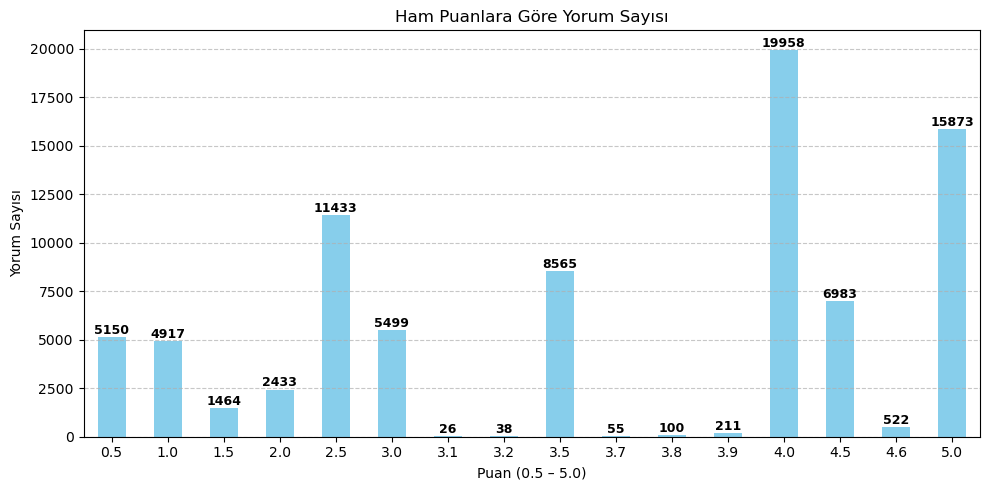

In [89]:
# 2. Convert scores to float (replace comma with dot)
df["class"] = df["point"].apply(lambda x: float(x.replace(",", ".")))

# 3. How many reviews per score?
puan_dagilimi = df["class"].value_counts().sort_index()

# 4. Print + plot
print("🎯 Number of reviews per score:\n")
print(puan_dagilimi)

# 5. Visualization
# Plot
ax = puan_dagilimi.plot(kind="bar", figsize=(10,5), color="skyblue")
plt.title("Ham Puanlara Göre Yorum Sayısı")
plt.xlabel("Puan (0.5 – 5.0)")
plt.ylabel("Yorum Sayısı")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

# 🔢 Write counts on top of bars
for i, value in enumerate(puan_dagilimi):
    ax.text(i, value + 5, str(int(value)), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()

## Relabeling, length filtering and balancing

In [91]:
# Clean labels: 0.5–2.5 = 0, 4.0–5.0 = 1
def clean_label(val):
    if 0.5 <= val <= 2.5:
        return 0
    elif 4.0 <= val <= 5.0:
        return 1
    else:
        return None

df["class"] = df["class"].apply(clean_label)
df = df[df["class"].notnull()].reset_index(drop=True)

# Count tokens
tokenizer = AutoTokenizer.from_pretrained("dbmdz/bert-base-turkish-cased")
df["token_count"] = df["comment"].apply(lambda x: len(tokenizer.tokenize(x)))

# Keep only reviews with at most 128 tokens
df = df[df["token_count"] <= 128].reset_index(drop=True)

# Take 5000 samples per class (balanced data)
df_neg = df[df["class"] == 0].sample(n=5000, random_state=42)
df_pos = df[df["class"] == 1].sample(n=5000, random_state=42)

# Combine into a balanced dataset
df = pd.concat([df_neg, df_pos]).sample(frac=1, random_state=42).reset_index(drop=True)

In [93]:
print(df["class"].value_counts())

class
1.0    5000
0.0    5000
Name: count, dtype: int64


In [95]:
# 4. Print examples and class distribution
print("🔴 Negative example:\n", df[df["class"]==0]["comment"].iloc[0])
print("🟢 Positive example:\n", df[df["class"]==1]["comment"].iloc[0])

🔴 Negative example:
 
                      Böyle fantastik bi kurguyu izlememek olmaz. Türk sineması bu türe daha çok eğilmeli.
        
            
🟢 Positive example:
 
                      bu tür senaryolara sahip çok film var ama bütün komedi filmlerin arasında en çok güldüren genelde bu türler. o yüzden böyle bi filmi izlerken hiç ön yargıyla izlemiyorum :)) çok güldüm çok eğlendim. chad michael murray uzun saçlı çok garipti olmuştu ;) herkese tavsiye ederim.
        
            


## Class and length distribution of the final dataset

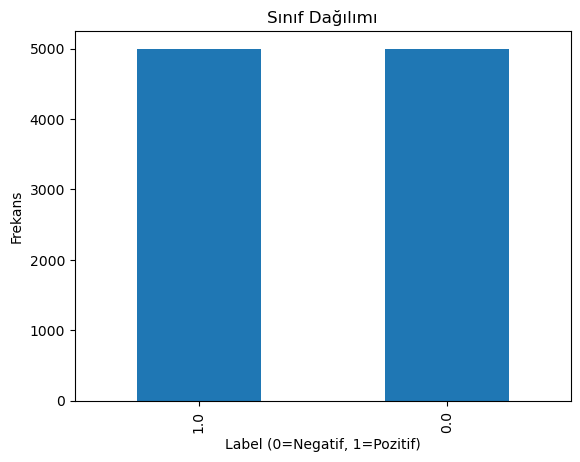

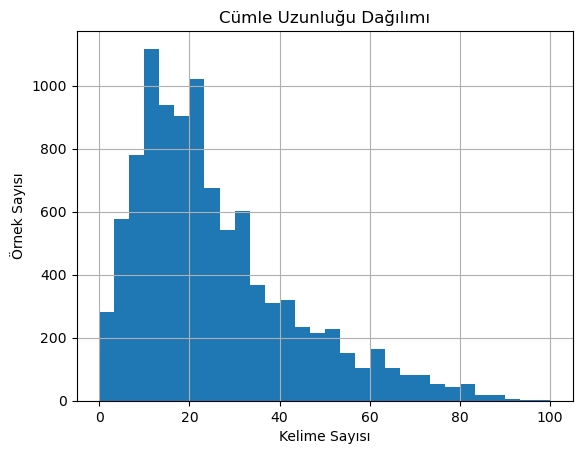

In [97]:
df["class"].value_counts().plot(kind="bar", title="Sınıf Dağılımı")
plt.xlabel("Label (0=Negatif, 1=Pozitif)")
plt.ylabel("Frekans")
plt.show()

# Create a sentence length (word count) column
df["length"] = df["comment"].apply(lambda x: len(str(x).split()))

# Plot histogram
df["length"].hist(bins=30)
plt.title("Cümle Uzunluğu Dağılımı")
plt.xlabel("Kelime Sayısı")
plt.ylabel("Örnek Sayısı")
plt.show()

In [99]:
df.to_csv("../data/balanced_movie_reviews.csv", index=False, encoding="utf-8-sig")

In [101]:
print(df["class"].unique())

[1. 0.]
